In [4]:
import os
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
from tqdm.notebook import tqdm  # Import tqdm specifically optimized for Jupyter

# 0. Define Dataset
dataset_version = "v08"

# 1. Load environment variables from your .env file
load_dotenv()
print("Connecting to PostgreSQL...")

# 2. Securely fetch the credentials
db_user = os.getenv("DB_USER")
db_password = os.getenv("DB_PASSWORD")
db_host = os.getenv("DB_HOST")
db_port = os.getenv("DB_PORT")
db_name = os.getenv("DB_NAME")

# 3. Construct the database URL and create the engine
db_url = f"postgresql://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}"
engine = create_engine(db_url)

# 4. Ask PostgreSQL exactly how many rows exist so the progress bar knows what 100% is
count_query = f"SELECT COUNT(*) FROM public.model_features_{dataset};"
total_rows = pd.read_sql(count_query, engine).iloc[0, 0]

# 5. Fetch the data in chunks and update the progress bar
query = f"SELECT * FROM public.model_features_{dataset};"
chunksize = 100000 
chunks = [] # We will store our data chunks here temporarily

print(f"Fetching {total_rows:,} engineered features from local database...")

# Create the progress bar
with tqdm(total=total_rows, desc="Downloading Data") as pbar:
    # Read the data in chunks
    for chunk in pd.read_sql(query, engine, chunksize=chunksize):
        chunks.append(chunk)      # Save the chunk
        pbar.update(len(chunk))   # Move the progress bar forward

# 6. Stitch all the chunks together into one massive DataFrame
df = pd.concat(chunks, ignore_index=True)

print(f"Success! Loaded {len(df):,} rows into local memory.")
display(df.head())

Connecting to PostgreSQL...
Fetching 5,732,926 engineered features from local database...


Success! Loaded 5,732,926 rows into local memory.


,MONTH,DAY,DAY_OF_WEEK,AIRLINE_ID,ORIGIN_AIRPORT_ID,DESTINATION_AIRPORT_ID,DISTANCE,SCHEDULED_DEPARTURE_TIME,ARRIVAL_HOUR,AIRLINE_HISTORIC_DELAY,...,DEST_PRECIPITATION,DEST_SNOWFALL,DEST_CLOUD_COVER_LOW,DEST_TEMPERATURE,DEST_SURFACE_PRESSURE,DEST_WEATHER_CODE,PREVIOUS_FLIGHT_DELAYED,ORIGIN_HOURLY_AIRPORT_TRAFFIC,DEST_HOURLY_AIRPORT_TRAFFIC,IS_DELAYED
0,2,10,2,2,204.0,295.0,1068,2105,23,9.70,...,0.0,0.0,0,0.3,999.2,0.0,0,24,4,0
1,7,7,2,2,87.0,199.0,469,850,10,11.10,...,0.0,0.0,6,28.4,1011.2,3.0,0,53,2,0
2,1,23,5,2,204.0,295.0,1068,2105,23,12.73,...,0.0,0.0,2,-3.3,996.2,1.0,0,25,4,0
3,9,23,3,2,87.0,199.0,469,850,10,10.07,...,0.0,0.0,29,25.9,1012.0,1.0,0,45,2,1
4,5,20,3,2,87.0,152.0,224,1205,13,10.66,...,0.2,0.0,29,28.1,1012.7,51.0,0,58,45,1


In [5]:
from sklearn.model_selection import train_test_split
import cupy as cp

print("Starting preprocessing...")

# 1. Drop columns we don't need for the predictive model
# relying on the ROUTE_HISTORIC_DELAY feature instead.
columns_to_drop = []
df_clean = df.drop(columns=columns_to_drop)

# 3. Separate your Features (X) from your Target (y)
X = df_clean.drop(columns=['IS_DELAYED'])
y = df_clean['IS_DELAYED']

# 4. Split the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert once, right after your train/test split — not inside the objective function
X_train_gpu = cp.array(X_train.values if hasattr(X_train, 'values') else X_train)
y_train_gpu = cp.array(y_train.values if hasattr(y_train, 'values') else y_train)

print("Preprocessing complete!")
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Starting preprocessing...
Preprocessing complete!
Training features shape: (4586340, 26)
Testing features shape: (1146586, 26)


In [9]:
from xgboost import XGBClassifier
import time

# Define training model version
model_type = "xgboost"
model_version = "v00"

print("Initializing XGBoost Classifier...")
# We use standard default parameters to establish a strong baseline
model = XGBClassifier(
    random_state=42, 
    eval_metric='logloss' # Tells the model how to measure its own errors during training
)

print("Training the model on 80% of the data. Please wait...")
start_time = time.time()

# This single line is where the actual math and "learning" happens
model.fit(X_train, y_train)

end_time = time.time()
print(f"Success! Training complete in {round(end_time - start_time, 2)} seconds.")

Initializing XGBoost Classifier...
Training the model on 80% of the data. Please wait...
Success! Training complete in 15.57 seconds.


In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import joblib

print("Evaluating model on the hidden test data...")

# 1. Ask the model to make predictions
y_pred = model.predict(X_test)

# 2. Print out the KPI metrics
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

# 3. Export the trained model to your hard drive
model_filename = f'models/model_{model_type}_{dataset}_{model_version}.joblib'
joblib.dump(model, model_filename)

print(f"\nBoom! Model fully trained, evaluated, and saved locally as: {model_filename}")

Evaluating model on the hidden test data...

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.96      0.92    942478
           1       0.70      0.41      0.52    204108

    accuracy                           0.86   1146586
   macro avg       0.79      0.69      0.72   1146586
weighted avg       0.85      0.86      0.85   1146586

--- Confusion Matrix ---
[[907274  35204]
 [120164  83944]]

Boom! Model fully trained, evaluated, and saved locally as: models/model_xgboost_v08_v00.joblib


PREVIOUS_FLIGHT_DELAYED            0.785120
ORIGIN_WEATHER_CODE                0.038938
ROUTE_HISTORIC_DELAY_BY_AIRLINE    0.031356
DEST_WEATHER_CODE                  0.017323
ARRIVAL_HOUR                       0.014343
MONTH                              0.009966
ORIGIN_HOURLY_AIRPORT_TRAFFIC      0.009104
SCHEDULED_DEPARTURE_TIME           0.009000
AIRLINE_ID                         0.007596
ORIGIN_CLOUD_COVER_LOW             0.007418
ORIGIN_PRECIPITATION               0.007312
DAY                                0.007012
DEST_CLOUD_COVER_LOW               0.006075
ORIGIN_TEMPERATURE                 0.005303
DEST_HOURLY_AIRPORT_TRAFFIC        0.004797
DAY_OF_WEEK                        0.004796
DISTANCE                           0.004066
DESTINATION_AIRPORT_ID             0.003932
ORIGIN_SNOWFALL                    0.003931
AIRLINE_HISTORIC_DELAY             0.003835
DEST_PRECIPITATION                 0.003721
DEST_SNOWFALL                      0.003592
DEST_TEMPERATURE                

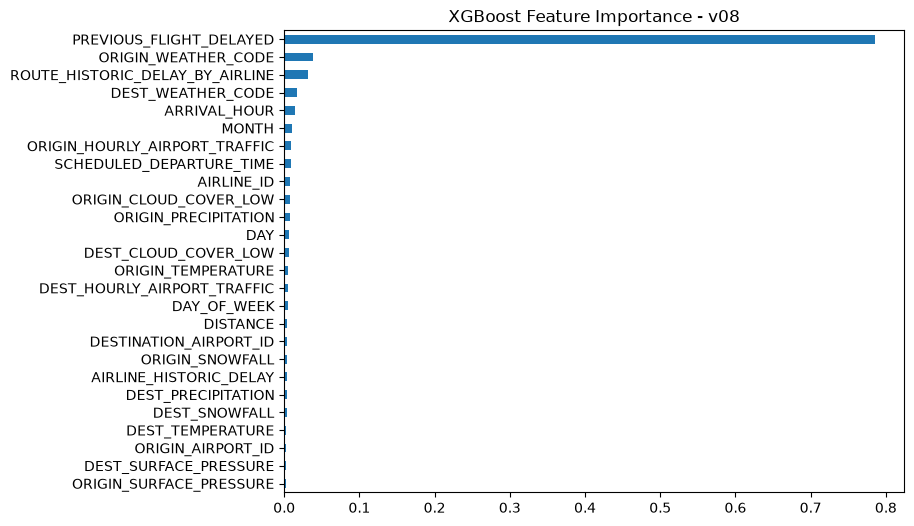

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)
print(importances)

importances.plot(kind='barh', figsize=(8,6))
plt.title('XGBoost Feature Importance - v08')
plt.gca().invert_yaxis()
plt.show()

In [12]:
weak_features = ["ORIGIN_PRECIPITATION","ORIGIN_SNOWFALL", "ORIGIN_TEMPERATURE", "ORIGIN_SURFACE_PRESSURE", "DEST_PRECIPITATION", "DEST_SNOWFALL", "DEST_TEMPERATURE", "DEST_SURFACE_PRESSURE"]

X_train_reduced = X_train.drop(columns=weak_features)
X_test_reduced = X_test.drop(columns=weak_features)

In [13]:
from xgboost import XGBClassifier
import time

# Define training model version
model_type = "xgboost"
model_version = "v00"

print("Initializing XGBoost Classifier...")
# We use standard default parameters to establish a strong baseline
model_reduced = XGBClassifier(
    random_state=42, 
    eval_metric='logloss' # Tells the model how to measure its own errors during training
)

print("Training the model on 80% of the data. Please wait...")
start_time = time.time()

# This single line is where the actual math and "learning" happens
model_reduced.fit(X_train_reduced, y_train)

end_time = time.time()
print(f"Success! Training complete in {round(end_time - start_time, 2)} seconds.")

Initializing XGBoost Classifier...
Training the model on 80% of the data. Please wait...
Success! Training complete in 13.06 seconds.


In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import joblib

print("Evaluating model on the hidden test data...")

# 1. Ask the model to make predictions
y_pred_reduced = model_reduced.predict(X_test_reduced)

# 2. Print out the KPI metrics
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_reduced))

print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred_reduced))

# 3. Export the trained model to your hard drive
model_filename = f'models/model_{model_type}_{dataset}_{model_version}_reduced.joblib'
joblib.dump(model_reduced, model_filename)

print(f"\nBoom! Model fully trained, evaluated, and saved locally as: {model_filename}")

Evaluating model on the hidden test data...

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.96      0.92    942478
           1       0.71      0.41      0.52    204108

    accuracy                           0.86   1146586
   macro avg       0.79      0.69      0.72   1146586
weighted avg       0.85      0.86      0.85   1146586

--- Confusion Matrix ---
[[907526  34952]
 [120560  83548]]

Boom! Model fully trained, evaluated, and saved locally as: models/model_xgboost_v08_v00_reduced.joblib


PREVIOUS_FLIGHT_DELAYED            0.808780
ROUTE_HISTORIC_DELAY_BY_AIRLINE    0.033953
ORIGIN_WEATHER_CODE                0.026605
ARRIVAL_HOUR                       0.016463
DEST_WEATHER_CODE                  0.013901
MONTH                              0.012838
ORIGIN_HOURLY_AIRPORT_TRAFFIC      0.010628
SCHEDULED_DEPARTURE_TIME           0.010500
DAY                                0.009893
AIRLINE_ID                         0.009437
ORIGIN_CLOUD_COVER_LOW             0.009132
DEST_CLOUD_COVER_LOW               0.008094
DEST_HOURLY_AIRPORT_TRAFFIC        0.005904
DAY_OF_WEEK                        0.005840
AIRLINE_HISTORIC_DELAY             0.005004
DISTANCE                           0.004834
DESTINATION_AIRPORT_ID             0.004107
ORIGIN_AIRPORT_ID                  0.004086
dtype: float32


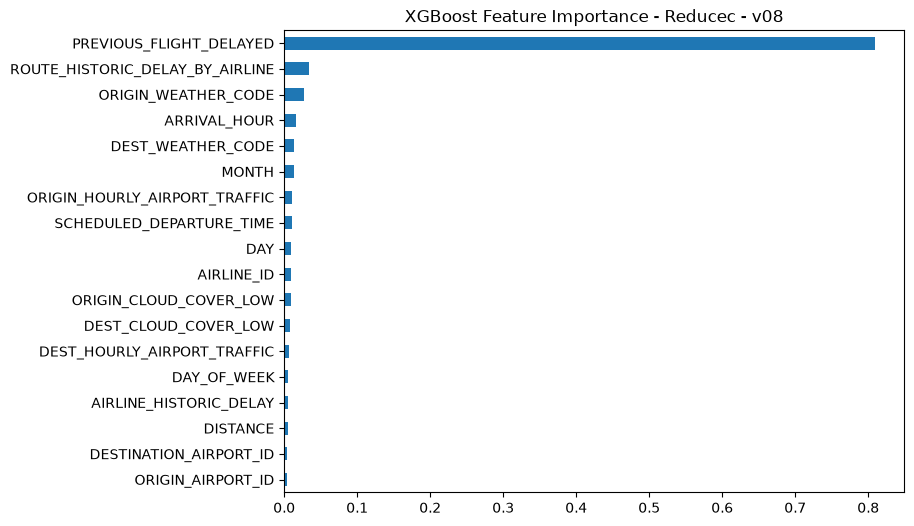

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(model_reduced.feature_importances_, index=X_train_reduced.columns)
importances = importances.sort_values(ascending=False)
print(importances)

importances.plot(kind='barh', figsize=(8,6))
plt.title('XGBoost Feature Importance - Reducec - v08')
plt.gca().invert_yaxis()
plt.show()

In [16]:
from xgboost import XGBClassifier
import time

# Define training model version
model_type = "xgboost"
model_version = "v01"

print("Calculating class imbalance...")
# Count the 0s (On Time) and divide by the 1s (Delayed)
# Based on your confusion matrix, this will be roughly 4.6
imbalance_ratio = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print(f"Imbalance Ratio: {round(imbalance_ratio, 2)} to 1")

print("\nInitializing Tuned XGBoost Classifier...")
model = XGBClassifier(
    random_state=42, 
    eval_metric='logloss',
    scale_pos_weight=imbalance_ratio  # <-- The magic parameter
)

print("Training the model. Please wait...")
start_time = time.time()
model.fit(X_train, y_train)
end_time = time.time()

print(f"Success! Training complete in {round(end_time - start_time, 2)} seconds.")

Calculating class imbalance...
Imbalance Ratio: 4.63 to 1

Initializing Tuned XGBoost Classifier...
Training the model. Please wait...
Success! Training complete in 16.08 seconds.


In [17]:
from sklearn.metrics import classification_report, confusion_matrix
import joblib

print("Evaluating model on the hidden test data...")

# 1. Ask the model to make predictions
y_pred = model.predict(X_test)

# 2. Print out the KPI metrics
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

# 3. Export the trained model to your hard drive
model_filename = f'models/model_{model_type}_{dataset}_{model_version}.joblib'
joblib.dump(model, model_filename)

print(f"\nBoom! Model fully trained, evaluated, and saved locally as: {model_filename}")

Evaluating model on the hidden test data...

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.92      0.83      0.87    942478
           1       0.45      0.65      0.54    204108

    accuracy                           0.80   1146586
   macro avg       0.68      0.74      0.70   1146586
weighted avg       0.83      0.80      0.81   1146586

--- Confusion Matrix ---
[[781094 161384]
 [ 70608 133500]]

Boom! Model fully trained, evaluated, and saved locally as: models/model_xgboost_v08_v01.joblib


PREVIOUS_FLIGHT_DELAYED            0.803355
ROUTE_HISTORIC_DELAY_BY_AIRLINE    0.032147
ORIGIN_WEATHER_CODE                0.025378
DEST_WEATHER_CODE                  0.018630
ARRIVAL_HOUR                       0.017334
MONTH                              0.010378
ORIGIN_HOURLY_AIRPORT_TRAFFIC      0.008240
DEST_CLOUD_COVER_LOW               0.007875
SCHEDULED_DEPARTURE_TIME           0.007441
ORIGIN_CLOUD_COVER_LOW             0.007113
DAY                                0.006431
ORIGIN_PRECIPITATION               0.006094
AIRLINE_ID                         0.006034
ORIGIN_TEMPERATURE                 0.005626
DAY_OF_WEEK                        0.004078
DEST_HOURLY_AIRPORT_TRAFFIC        0.003931
DESTINATION_AIRPORT_ID             0.003823
DISTANCE                           0.003779
AIRLINE_HISTORIC_DELAY             0.003692
DEST_PRECIPITATION                 0.003415
ORIGIN_AIRPORT_ID                  0.003027
DEST_TEMPERATURE                   0.003014
ORIGIN_SNOWFALL                 

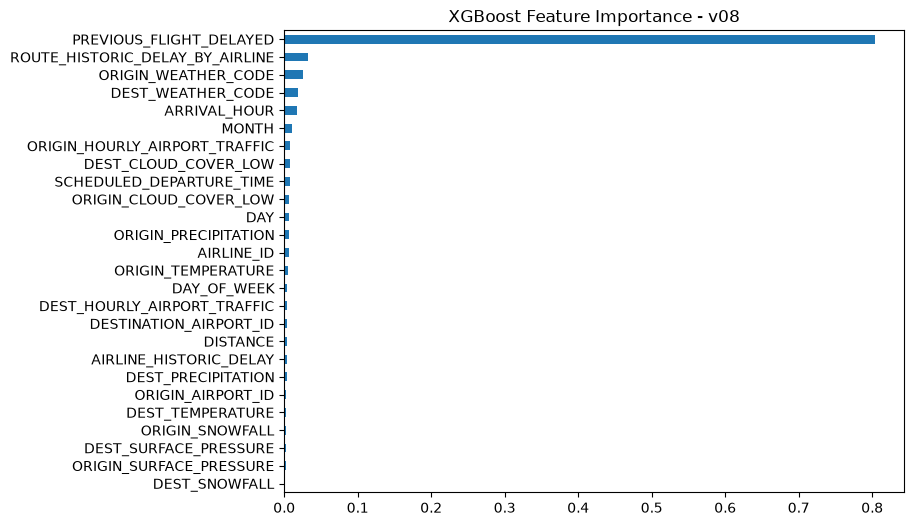

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)
print(importances)

importances.plot(kind='barh', figsize=(8,6))
plt.title('XGBoost Feature Importance - v08')
plt.gca().invert_yaxis()
plt.show()

In [19]:
weak_features = ["ORIGIN_PRECIPITATION","ORIGIN_SNOWFALL", "ORIGIN_TEMPERATURE", "ORIGIN_SURFACE_PRESSURE", "DEST_PRECIPITATION", "DEST_SNOWFALL", "DEST_TEMPERATURE", "DEST_SURFACE_PRESSURE"]

X_train_reduced = X_train.drop(columns=weak_features)
X_test_reduced = X_test.drop(columns=weak_features)

In [20]:
from xgboost import XGBClassifier
import time

# Define training model version
model_type = "xgboost"
model_version = "v01"

print("Calculating class imbalance...")
# Count the 0s (On Time) and divide by the 1s (Delayed)
# Based on your confusion matrix, this will be roughly 4.6
imbalance_ratio = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print(f"Imbalance Ratio: {round(imbalance_ratio, 2)} to 1")

print("\nInitializing Tuned XGBoost Classifier...")
model_reduced = XGBClassifier(
    random_state=42, 
    eval_metric='logloss',
    scale_pos_weight=imbalance_ratio  # <-- The magic parameter
)

print("Training the model. Please wait...")
start_time = time.time()
model_reduced.fit(X_train_reduced, y_train)
end_time = time.time()

print(f"Success! Training complete in {round(end_time - start_time, 2)} seconds.")

Calculating class imbalance...
Imbalance Ratio: 4.63 to 1

Initializing Tuned XGBoost Classifier...
Training the model. Please wait...
Success! Training complete in 13.6 seconds.


In [21]:
from sklearn.metrics import classification_report, confusion_matrix
import joblib

print("Evaluating model on the hidden test data...")

# 1. Ask the model to make predictions
y_pred_reduced = model_reduced.predict(X_test_reduced)

# 2. Print out the KPI metrics
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_reduced))

print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred_reduced))

# 3. Export the trained model to your hard drive
model_filename = f'models/model_{model_type}_{dataset}_{model_version}_reduced.joblib'
joblib.dump(model_reduced, model_filename)

print(f"\nBoom! Model fully trained, evaluated, and saved locally as: {model_filename}")

Evaluating model on the hidden test data...

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.92      0.83      0.87    942478
           1       0.45      0.65      0.53    204108

    accuracy                           0.80   1146586
   macro avg       0.68      0.74      0.70   1146586
weighted avg       0.83      0.80      0.81   1146586

--- Confusion Matrix ---
[[781064 161414]
 [ 70994 133114]]

Boom! Model fully trained, evaluated, and saved locally as: models/model_xgboost_v08_v01_reduced.joblib


PREVIOUS_FLIGHT_DELAYED            0.815516
ROUTE_HISTORIC_DELAY_BY_AIRLINE    0.037671
ORIGIN_WEATHER_CODE                0.023777
ARRIVAL_HOUR                       0.018366
DEST_WEATHER_CODE                  0.014468
MONTH                              0.012085
SCHEDULED_DEPARTURE_TIME           0.009604
ORIGIN_CLOUD_COVER_LOW             0.009524
ORIGIN_HOURLY_AIRPORT_TRAFFIC      0.009226
DAY                                0.008712
DEST_CLOUD_COVER_LOW               0.007409
AIRLINE_ID                         0.006687
DAY_OF_WEEK                        0.005335
AIRLINE_HISTORIC_DELAY             0.004683
DISTANCE                           0.004619
DEST_HOURLY_AIRPORT_TRAFFIC        0.004399
DESTINATION_AIRPORT_ID             0.004328
ORIGIN_AIRPORT_ID                  0.003591
dtype: float32


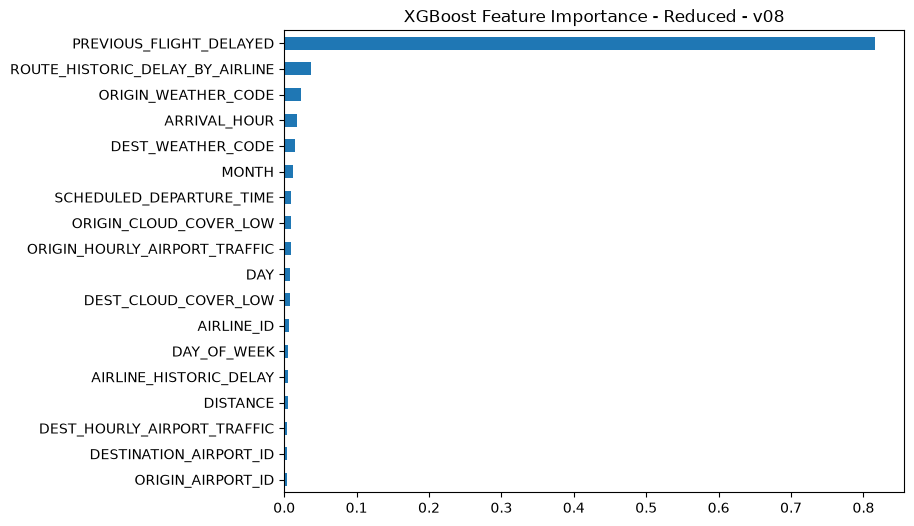

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(model_reduced.feature_importances_, index=X_train_reduced.columns)
importances = importances.sort_values(ascending=False)
print(importances)

importances.plot(kind='barh', figsize=(8,6))
plt.title('XGBoost Feature Importance - Reduced - v08')
plt.gca().invert_yaxis()
plt.show()

In [24]:
from xgboost import XGBClassifier
import time

# Define training model version
model_type = "xgboost"
model_version = "v02"

print("\nInitializing Tuned XGBoost Classifier...")
model = XGBClassifier(
    random_state=42, 
    eval_metric='logloss',
    max_depth = 3,
    learning_rate = 0.01
)

print("Training the model. Please wait...")
start_time = time.time()
model.fit(X_train, y_train)
end_time = time.time()

print(f"Success! Training complete in {round(end_time - start_time, 2)} seconds.")


Initializing Tuned XGBoost Classifier...
Training the model. Please wait...
Success! Training complete in 11.49 seconds.


In [25]:
from sklearn.metrics import classification_report, confusion_matrix
import joblib

print("Evaluating model on the hidden test data...")

# 1. Ask the model to make predictions
y_pred = model.predict(X_test)

# 2. Print out the KPI metrics
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

# 3. Export the trained model to your hard drive
model_filename = f'models/model_{model_type}_{dataset}_{model_version}.joblib'
joblib.dump(model, model_filename)

print(f"\nBoom! Model fully trained, evaluated, and saved locally as: {model_filename}")

Evaluating model on the hidden test data...

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.84      0.99      0.91    942478
           1       0.76      0.16      0.26    204108

    accuracy                           0.84   1146586
   macro avg       0.80      0.57      0.59   1146586
weighted avg       0.83      0.84      0.80   1146586

--- Confusion Matrix ---
[[932427  10051]
 [171929  32179]]

Boom! Model fully trained, evaluated, and saved locally as: models/model_xgboost_v08_v02.joblib


PREVIOUS_FLIGHT_DELAYED            0.883647
ROUTE_HISTORIC_DELAY_BY_AIRLINE    0.032320
ARRIVAL_HOUR                       0.019349
SCHEDULED_DEPARTURE_TIME           0.015882
ORIGIN_WEATHER_CODE                0.009536
ORIGIN_HOURLY_AIRPORT_TRAFFIC      0.007771
DEST_WEATHER_CODE                  0.007398
AIRLINE_HISTORIC_DELAY             0.006909
ORIGIN_TEMPERATURE                 0.006795
DEST_HOURLY_AIRPORT_TRAFFIC        0.005778
AIRLINE_ID                         0.004614
DAY_OF_WEEK                        0.000000
DISTANCE                           0.000000
DESTINATION_AIRPORT_ID             0.000000
MONTH                              0.000000
DAY                                0.000000
ORIGIN_AIRPORT_ID                  0.000000
ORIGIN_PRECIPITATION               0.000000
DEST_PRECIPITATION                 0.000000
ORIGIN_SURFACE_PRESSURE            0.000000
ORIGIN_SNOWFALL                    0.000000
ORIGIN_CLOUD_COVER_LOW             0.000000
DEST_SURFACE_PRESSURE           

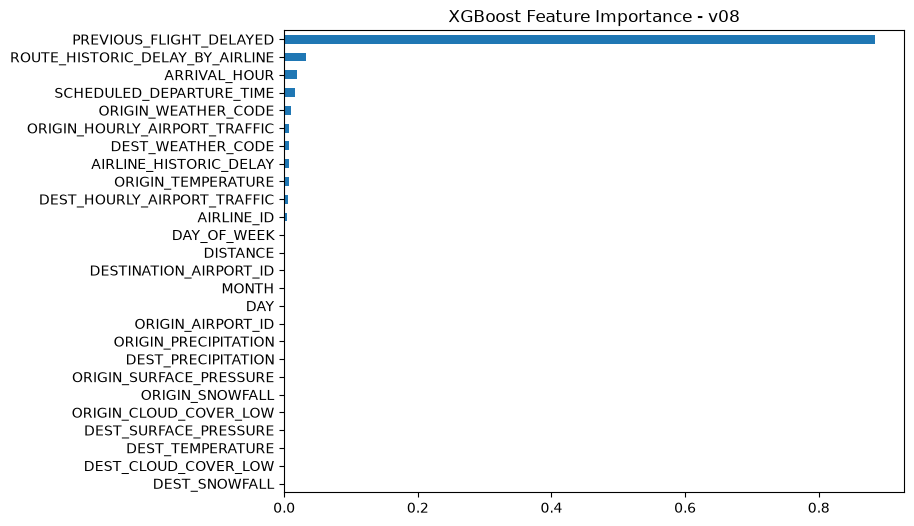

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)
print(importances)

importances.plot(kind='barh', figsize=(8,6))
plt.title('XGBoost Feature Importance - v08')
plt.gca().invert_yaxis()
plt.show()